# **Financial Inclusion Project:** Telco Customer Churn Analysis and Prediction 
## Problem Statement
Customer churning affect the business expectation negatively whereby the company loose their customers

## Solution 
Creating a platform (Streamlit) where companies can enter data of their customer to help early detection of churners and take necessary steps to retain such customer.

## Data Preparation 


### Importing Required Libraries

In this section, the necessary Python libraries for data analysis and preprocessing are imported.

- `pandas` and `numpy` are used for data manipulation and numerical operations.
- `os` is used to allow code interact with files, folders, paths, and directories.
- `Warnings` are suppressed to keep the notebook output clean and focused.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn import tree 
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline, make_pipeline
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier, plot_importance
import pickle

### Loading the Dataset

The Telco Customer Churn dataset is loaded into a pandas DataFrame.  
This dataset contains customer demographic information, service usage details, billing information, and churn status.

The goal is to analyze these features and prepare the data for churn prediction modeling.


In [2]:
df=pd.read_csv("Telco_Customer_Churn_Dataset  (3).csv")

### Previewing the Dataset

The first few rows of the dataset are displayed to:
- Understand the structure of the data
- Identify the types of variables available
- Confirm that the dataset was loaded correctly


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Dataset Dimensions

The shape of the dataset is examined to determine:
- The total number of observations (rows)
- The total number of features (columns)

This helps assess the size of the dataset and its suitability for analysis.


In [4]:
df.shape

(7043, 21)

**Observation:**  
The dataset contains **7043 rows** and **21 columns**.


### Column Names

The column names are displayed to understand the features available in the dataset.
This includes customer demographics, service subscriptions, billing details, and the target variable (`Churn`).


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Dataset Information and Data Types

The `info()` method is used to:
- Inspect data types of each column
- Identify categorical and numerical variables
- Detect potential issues such as incorrect data types or missing values


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Key observations:**
- Most variables are categorical (`object` type).
- `SeniorCitizen` is encoded numerically but represents a categorical variable.
- `TotalCharges` is stored as an object instead of a numeric type.


### Converting TotalCharges to Numeric

The `TotalCharges` column is converted from an object type to a numeric type.

Some values in this column are stored as empty strings, which prevents direct conversion.  
By setting `errors="coerce"`, invalid entries are converted to `NaN`, making it possible to identify missing values.


In [7]:
df["TotalCharges"]= pd.to_numeric(df["TotalCharges"], errors="coerce")

### Converting SeniorCitizen to Categorical

Although `SeniorCitizen` is represented numerically (0 or 1), it is a categorical variable rather than a continuous numerical feature.

Converting it to an object type ensures it is treated correctly during analysis and encoding.


In [8]:
df["SeniorCitizen"]=df["SeniorCitizen"].astype(object)

### Re-checking Dataset Information

The dataset structure is reviewed again after data type conversions to confirm that:
- `TotalCharges` is now numeric
- `SeniorCitizen` is treated as a categorical variable


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Identifying Missing Values

The number of missing values in the `TotalCharges` column is counted.
This step is necessary to determine the appropriate missing value handling strategy.


In [10]:
df["TotalCharges"].isna().sum()

np.int64(11)

**Observation:**  
There are **11 missing values** in the `TotalCharges` column.


### Handling Missing Values

Since the number of missing values is very small relative to the dataset size, the affected rows are removed.

Dropping these rows is unlikely to introduce bias and helps maintain data quality.


In [11]:
df.dropna(inplace=True)

### Final Dataset Check

After handling missing values, the dataset information is reviewed one final time to confirm:
- No remaining missing values
- Correct data types
- Dataset is ready for further analysis and modeling


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   object 
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

**Final Dataset Summary:**
- Total observations after cleaning: **7032**
- Total features: **21**
- Dataset is now clean and suitable for exploratory analysis and modeling.


In [13]:
# Saving the cleaned dataset to the created folder in my Drive
df.to_csv("cleaned_telco_customer_churn_data.csv", index=False)


## Exploratory Data Analysis (EDA)



In [14]:
#Loading the cleaned dataset for exploration and further processing
df = pd.read_csv("cleaned_telco_customer_churn_data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [16]:
df["SeniorCitizen"]=df["SeniorCitizen"].astype("object")

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   object 
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


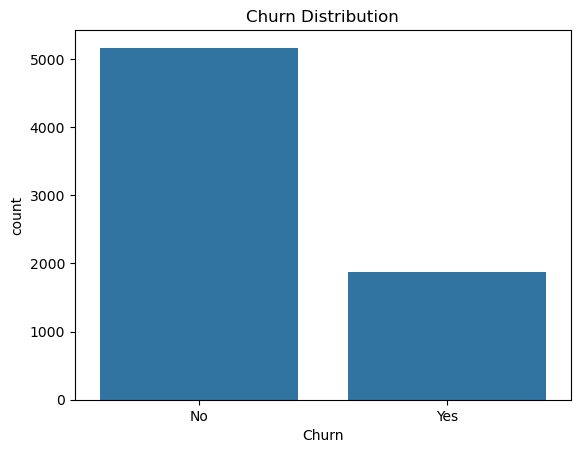

In [18]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()


In [19]:
# Percent of churned and non-churned customers
percent_churn = df["Churn"].value_counts(normalize=True) * 100
percent_churn = percent_churn.round(2)

print(percent_churn)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


### Churn Distribution

The churn distribution is calculated as the proportion of customers who have churned (`Yes`) in the `Churn` column, where:  
- `Yes` represents customers who churned  
- `No` represents customers who did not churn  

**Observation:**  
The overall churn rate is approximately **26.58%**, indicating that about **one in four customers leave the service**.  

**Insight:**  
While the majority of customers (73.42%) remain active, a **significant minority are churning**. This suggests there is room to improve customer retention strategies, and predictive modeling can help identify which customers are at risk of leaving.

This distribution indicates a **moderate class imbalance**, which is important to consider when building a predictive model for customer churn.

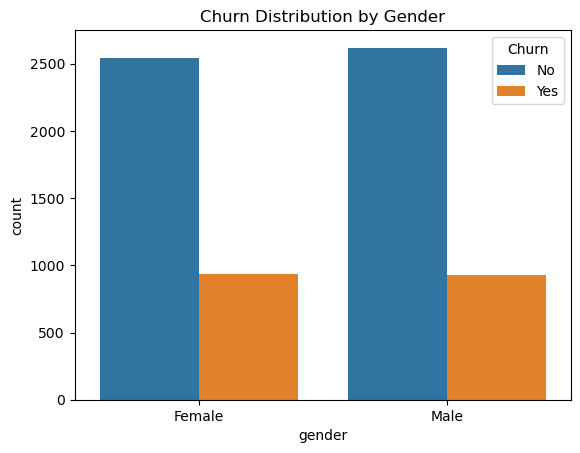

In [20]:
# Visualize churn by gender
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Churn Distribution by Gender")
plt.show()

### Churn Rate by Gender

This plot compares churn rates across genders.

**Insight:**  
The churn rate among **female** customers is slightly **higher** than **male**, suggesting that gender has **minimal** influence on churn.

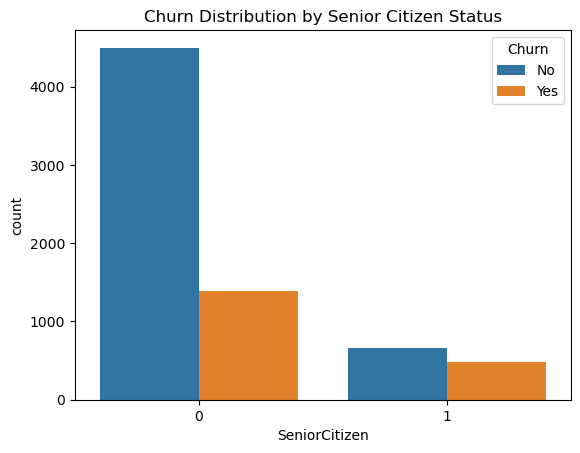

In [21]:
# Visualize churn by senior citizen
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)
plt.title("Churn Distribution by Senior Citizen Status")
plt.show()

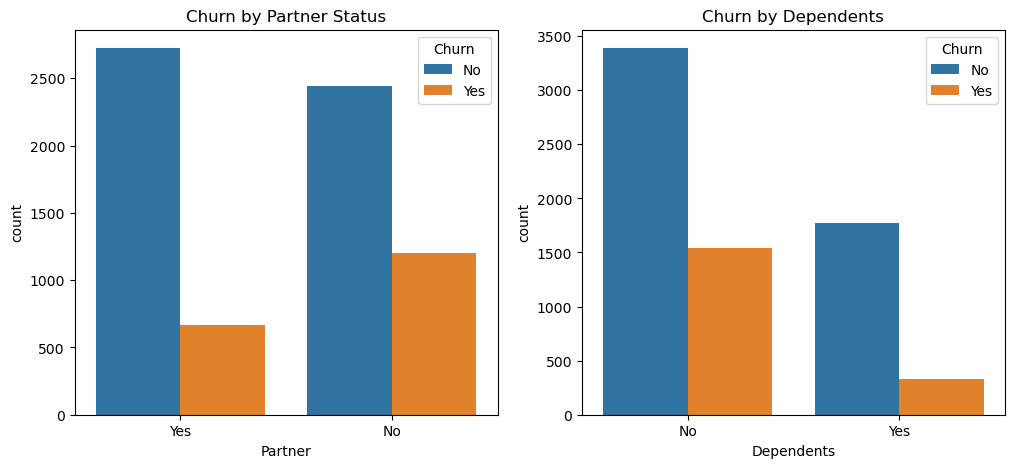

In [22]:
# Visualize churn by senior citizen
fig, ax= plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="Partner", hue="Churn", data=df, ax=ax[0])
sns.countplot(x="Dependents", hue="Churn", data=df, ax=ax[1])

ax[0].set_title("Churn by Partner Status")
ax[1].set_title("Churn by Dependents")

plt.show()

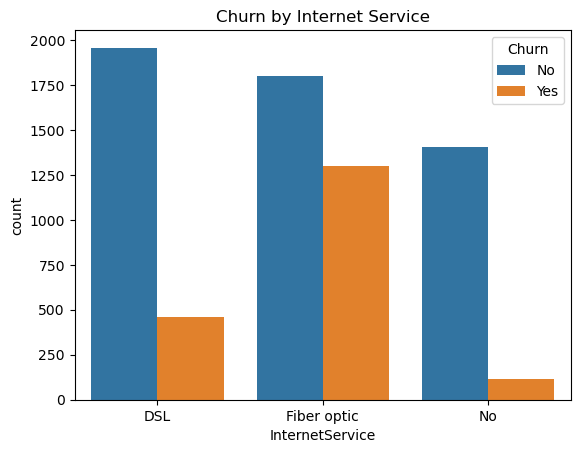

In [23]:
# Visualize churn by Internet Service
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by Internet Service")
plt.show()

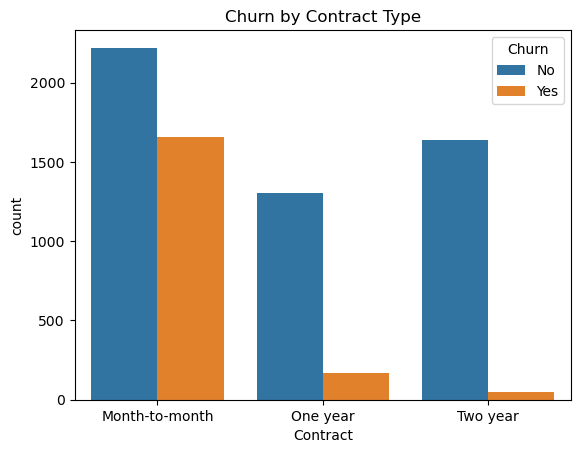

In [24]:
# Visualize churn by Contract
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

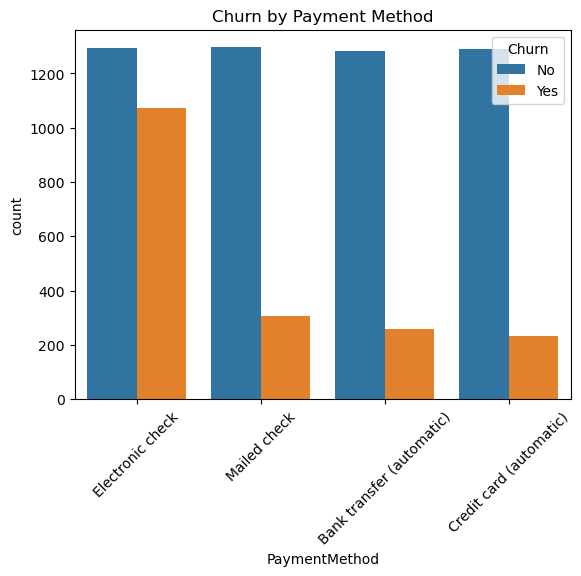

In [25]:
# Visualize churn by Payment Method
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

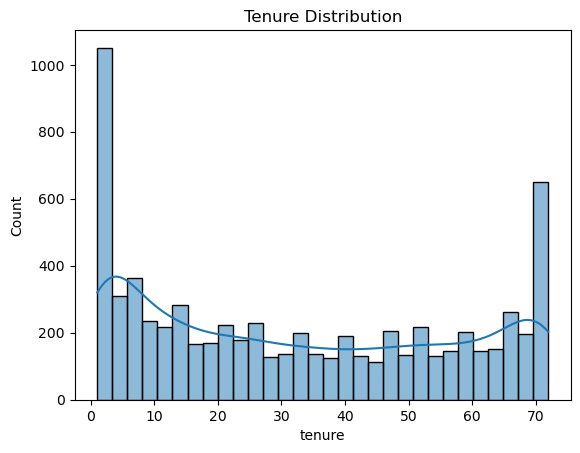

In [26]:
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Tenure Distribution")
plt.show()

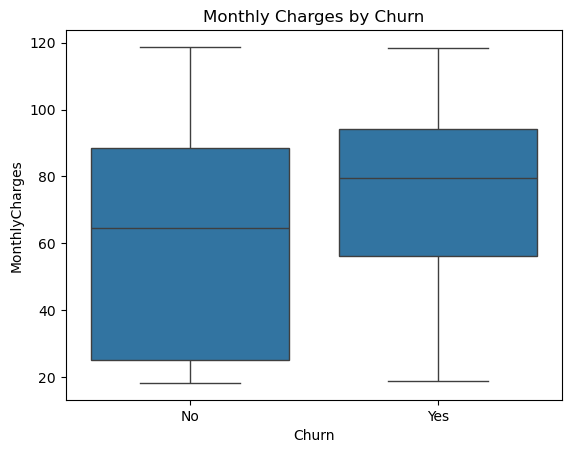

In [27]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.show()

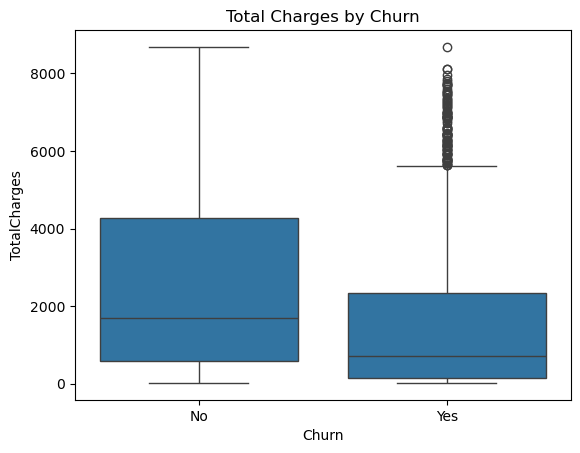

In [28]:
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("Total Charges by Churn")
plt.show()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   object 
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


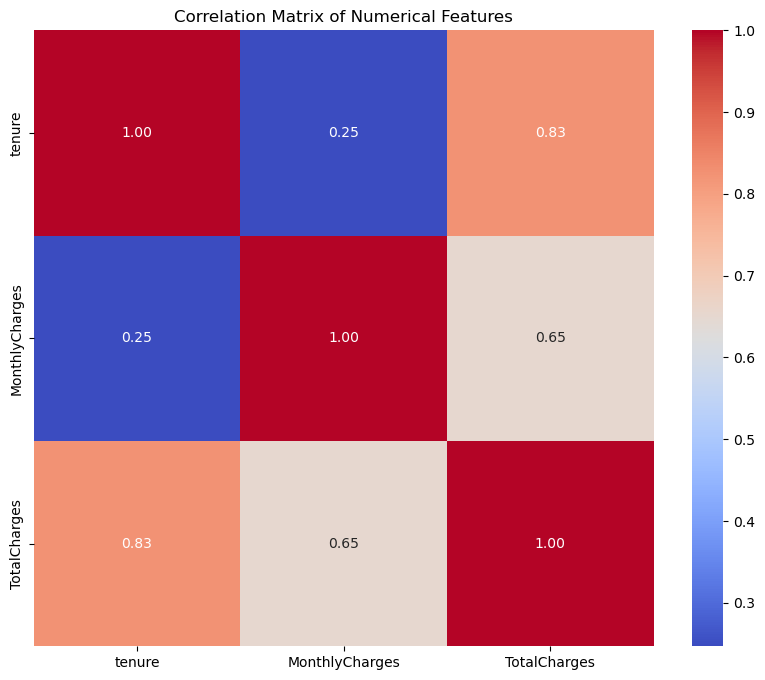

In [30]:
# Select only numeric columns automatically
numeric_df = df.select_dtypes(include=np.number)

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## Model Building

In this section, different machine learning algorithms are trained to predict **customer churn**. Since churn prediction is a **binary classification problem**, several classification models are implemented and compared.

The models used include:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- XGBoost

The models are evaluated using the following metrics:

- Accuracy Score
- Confusion Matrix
- Classification Report
- ROC-AUC Score

### Common Setup
- The necessary libraries are imported to handle data preprocessing, model training, and evaluation.
- `StandardScaler` is used for scaling numerical features where needed.
- `OneHotEncoder` and `LabelEncoder` are applied depending on the model requirements.
- The dataset is split into features (`X`) and target (`y`), followed by a **train-test split** to evaluate model performance.

In [31]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [32]:
#Dropping the customerID column as including it in the dataset may cause bias for the models
df=df.drop("customerID",axis=1)

In [33]:
#verifying if the customerID column has been truly dropped
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [34]:
# One-hot encode categorical variables
df_lr = pd.get_dummies(df, drop_first=True)

In [35]:
#Splittting the dataset into features (X) and the target (y)
X = df_lr.drop("Churn_Yes", axis=1)

model_columns = X.columns.tolist()

y = df_lr["Churn_Yes"]

print(len(model_columns))

30


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [37]:
# Logistic Regression with class weights for class imbalance
lr = LogisticRegression(class_weight="balanced", max_iter=1000)
lr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [38]:
# Using StandardScaler for scaling numerical features
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", lr)
])


In [39]:
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]

## Baseline Model: Logistic Regression
### (One-Hot Encoding + Standard Scaling + Class Weights)

Logistic Regression is a widely used algorithm for **binary classification problems**. It predicts the probability that a given input belongs to a particular class.

In this project:

- The model is trained to predict whether a customer will **churn or not**.
- Simple and interpretable.
- Serves as the baseline for comparison.
- **Class weights are balanced** to handle the imbalance in the dataset.
- A **pipeline with StandardScaler** is used to standardize numerical features before training the model.
- **One-Hot Encoding** to handle categorical variables 

After training the model, we evaluate its performance using classification metrics.

In [40]:
accuracy_score(y_test, y_pred_lr)

0.7263681592039801

In [41]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

       False       0.91      0.70      0.79      1033
        True       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



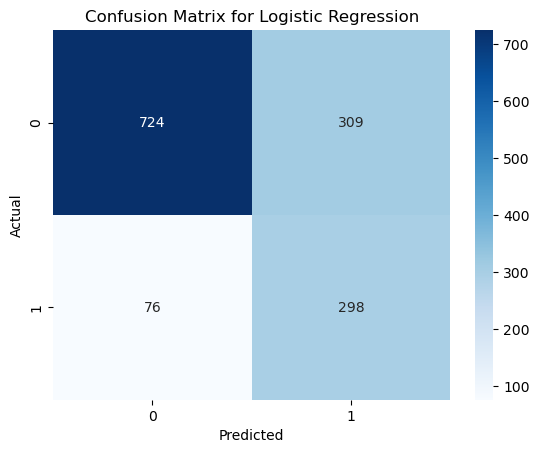

In [42]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [43]:
# Compute AUC (Area Under the Curve)
auc_score_lr = roc_auc_score(y_test, y_pred_lr)
print("AUC Score:", round(auc_score_lr, 3))

AUC Score: 0.749


In [44]:
# Get feature names
feature_names = X.columns

# Extract coefficients from the trained pipeline
coefficients = pipe_lr.named_steps["model"].coef_[0]

# Create dataframe
lr_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
})

# Sort by importance
lr_feature_importance = lr_feature_importance.sort_values(
    by="Absolute_Coefficient", ascending=False
)

lr_feature_importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
0,tenure,-1.263854,1.263854
1,MonthlyCharges,-0.928682,0.928682
10,InternetService_Fiber optic,0.746144,0.746144
25,Contract_Two year,-0.638598,0.638598
2,TotalCharges,0.623279,0.623279
24,Contract_One year,-0.326693,0.326693
21,StreamingTV_Yes,0.259691,0.259691
23,StreamingMovies_Yes,0.252870,0.252870
9,MultipleLines_Yes,0.202763,0.202763
28,PaymentMethod_Electronic check,0.193697,0.193697


### Feature Importance – Logistic Regression

Logistic Regression coefficients provide insight into the **importance of features** in predicting customer churn. Features with higher absolute coefficient values have a stronger influence on the prediction.

The visualization below highlights the most influential features affecting churn.

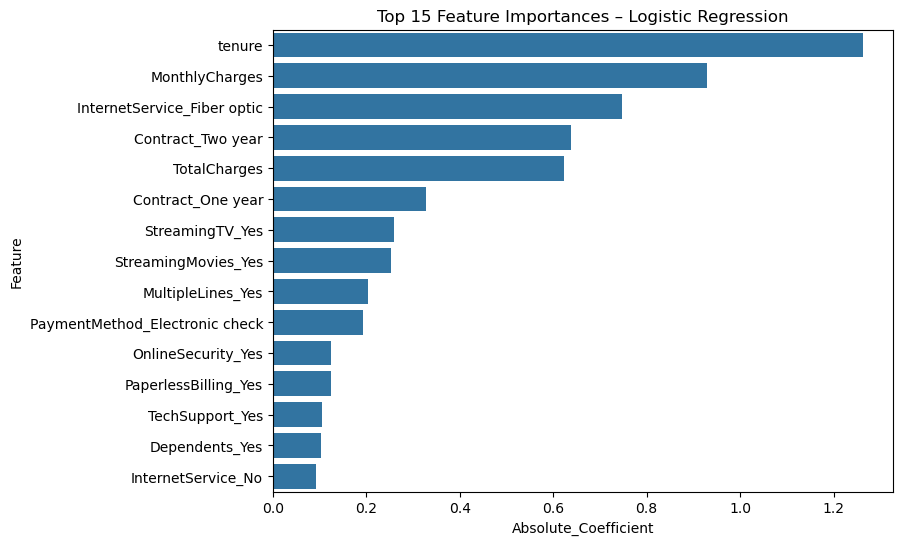

In [45]:
plt.figure(figsize=(8,6))
sns.barplot(
    x="Absolute_Coefficient",
    y="Feature",
    data=lr_feature_importance.head(15)
)
plt.title("Top 15 Feature Importances – Logistic Regression")
plt.show()

## Decision Tree Model
### (Label Encoding + No Scaling + Class Weights)

Decision Trees are supervised learning models that split the dataset into branches based on feature values. Each split attempts to improve the separation between classes.

Advantages of Decision Trees include:

- Easy interpretability
- Ability to capture non-linear relationships
- Automatic feature selection

The model is trained using **balanced class weights** to address class imbalance & scaling is not done for the decision tree model as it is an ensemble model.

In [46]:
# Decision Tree with class weights for class imbalance
dt_model = DecisionTreeClassifier(class_weight="balanced", max_depth=5, random_state=42)
dt_model

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [47]:
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [48]:
accuracy_score(y_test, y_pred_dt)

0.7057569296375267

In [49]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

       False       0.90      0.68      0.77      1033
        True       0.47      0.78      0.59       374

    accuracy                           0.71      1407
   macro avg       0.68      0.73      0.68      1407
weighted avg       0.78      0.71      0.72      1407



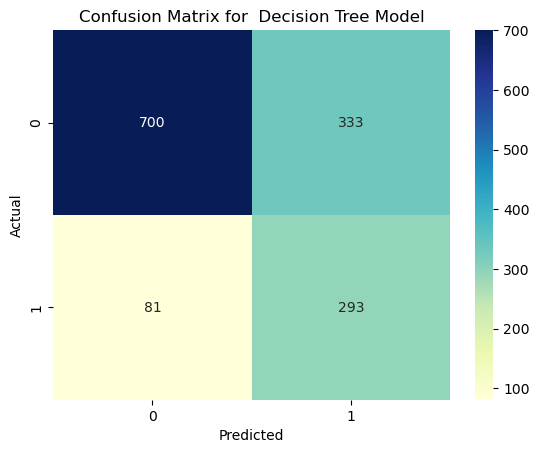

In [50]:
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix for  Decision Tree Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
# Compute AUC (Area Under the Curve)
auc_score_dt = roc_auc_score(y_test, y_pred_dt)
print("AUC Score:", round(auc_score_dt, 3))

AUC Score: 0.731


In [52]:
dt_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

dt_feature_importance

,Feature,Importance
25,Contract_Two year,0.397662
24,Contract_One year,0.264054
10,InternetService_Fiber optic,0.101743
0,tenure,0.098646
23,StreamingMovies_Yes,0.034495
28,PaymentMethod_Electronic check,0.031568
1,MonthlyCharges,0.024853
2,TotalCharges,0.019290
11,InternetService_No,0.017820
6,Dependents_Yes,0.007072


### Feature Importance – Decision Tree

Decision Trees calculate feature importance based on how much each feature contributes to reducing impurity during the splitting process.

The plot below shows the most important features influencing customer churn prediction.

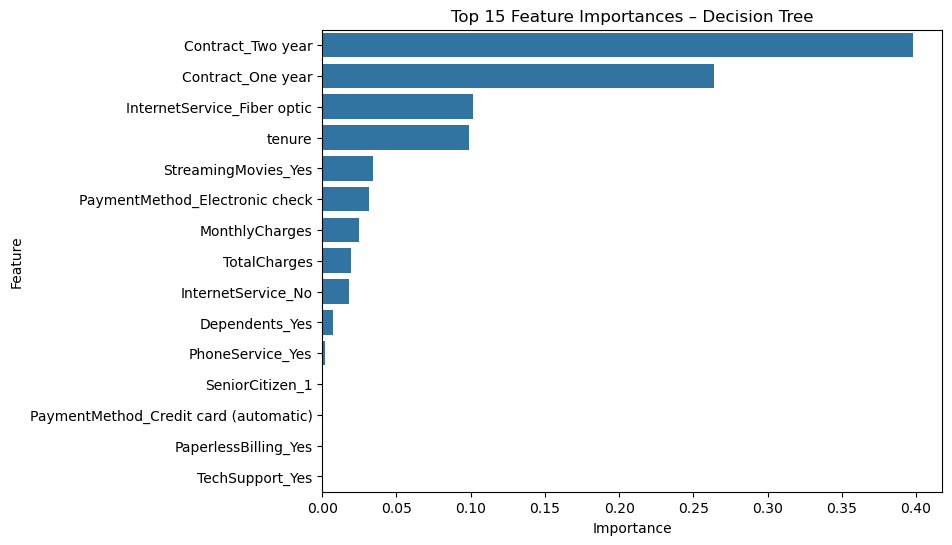

In [53]:
plt.figure(figsize=(8,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=dt_feature_importance.head(15)
)
plt.title("Top 15 Feature Importances – Decision Tree")
plt.show()

## Random Forest Model

Random Forest is an **ensemble learning algorithm** that builds multiple decision trees and combines their predictions to produce a more robust model.

Key characteristics of Random Forest include:

- Reduction of overfitting
- Improved predictive accuracy
- Ability to handle large datasets with many features

The model is trained with **balanced class weights** to handle the class imbalance in the dataset. Also, scaling is not necessary here as random forest is also an ensemble model.

In [54]:
# Label encode categorical features
df_rf = df.copy()
le = LabelEncoder()

for col in df_rf.select_dtypes(include="object").columns:
    df_rf[col] = le.fit_transform(df_rf[col])

In [55]:
X = df_rf.drop("Churn", axis=1)
y = df_rf["Churn"]


In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [57]:
# Random Forest with class weights for class imbalance
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [59]:
accuracy_score(y_test, y_pred_rf)

0.7810945273631841

In [60]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1033
           1       0.61      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



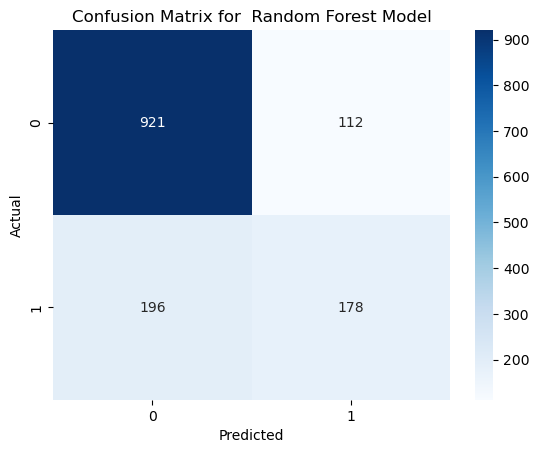

In [61]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for  Random Forest Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [62]:
# Compute AUC (Area Under the Curve)
auc_score_rf = roc_auc_score(y_test, y_pred_rf)
print("AUC Score:", round(auc_score_rf, 3))

AUC Score: 0.684


In [63]:
rf_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_feature_importance.head(10)

,Feature,Importance
18,TotalCharges,0.168290
17,MonthlyCharges,0.163161
4,tenure,0.149012
14,Contract,0.116285
8,OnlineSecurity,0.055238
11,TechSupport,0.053644
16,PaymentMethod,0.049820
9,OnlineBackup,0.028098
7,InternetService,0.027918
0,gender,0.026306


### Feature Importance – Random Forest

Random Forest provides feature importance scores based on how much each feature contributes to reducing impurity across all decision trees.

The following visualization shows the top features influencing customer churn prediction.

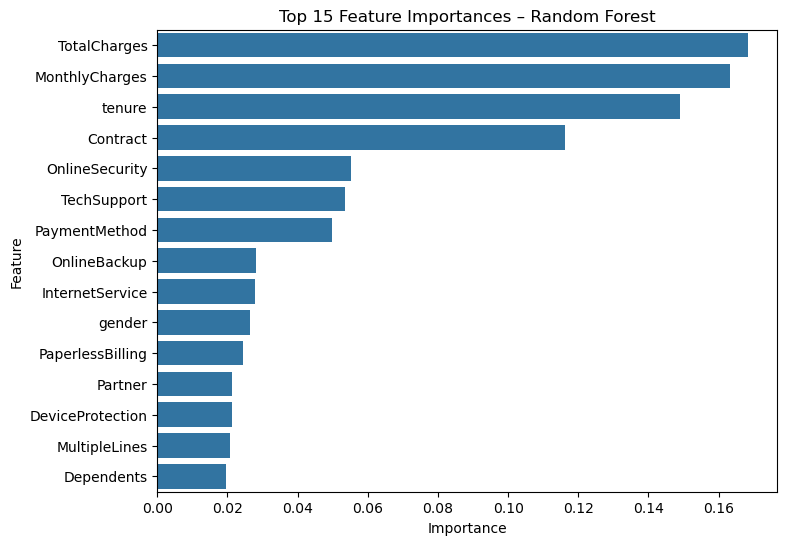

In [64]:
plt.figure(figsize=(8,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_feature_importance.head(15)
)
plt.title("Top 15 Feature Importances – Random Forest")
plt.show()

## K-Nearest Neighbors (KNN) Model

K-Nearest Neighbors (KNN) is a **distance-based classification algorithm**. It classifies a new observation based on the majority class of its nearest neighbors.

The algorithm works by:

1. Calculating the distance between data points
2. Selecting the **K nearest neighbors**
3. Assigning the class that appears most frequently among them

In [65]:
#Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
knn= KNeighborsClassifier(n_neighbors=13)
knn.fit(X,y)

,n_neighbors,13
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [67]:
train_accuracies={}
test_accuracies={}
neighbors=np.arange(1,30)
for neighbor in neighbors:
    knn=KNeighborsClassifier(neighbor)
    knn.fit(X_train, y_train)
    train_accuracies[neighbor]=knn.score(X_train, y_train)
    test_accuracies[neighbor]=knn.score(X_test, y_test)

### Selecting the Optimal Number of Neighbors

To determine the best value of **K**, the model is trained with different neighbor values. Training and testing accuracy scores are recorded for each value.

The plot below illustrates how model accuracy changes as the number of neighbors increases.

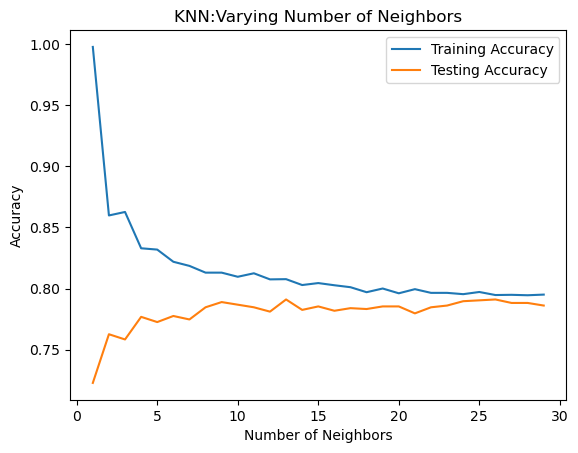

In [68]:
plt.figure()
plt.title("KNN:Varying Number of Neighbors")
plt.plot(neighbors, train_accuracies.values(), label="Training Accuracy")
plt.plot(neighbors, test_accuracies.values(), label="Testing Accuracy")
plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.show()

In [69]:
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

In [70]:
accuracy_score(y_test, y_pred_knn)

0.7860696517412935

In [71]:
print(classification_report(y_test, y_pred_knn))


              precision    recall  f1-score   support

           0       0.80      0.94      0.87      1033
           1       0.69      0.36      0.47       374

    accuracy                           0.79      1407
   macro avg       0.74      0.65      0.67      1407
weighted avg       0.77      0.79      0.76      1407



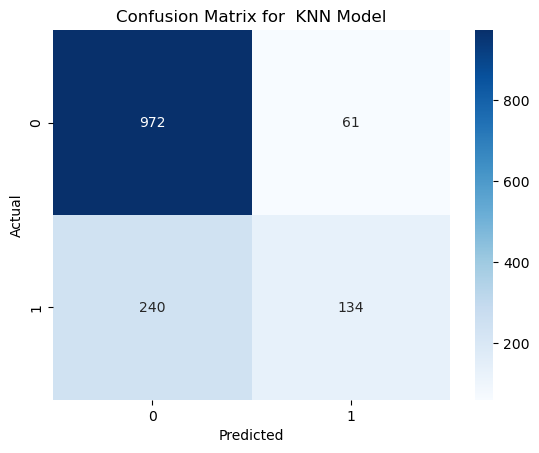

In [72]:
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for  KNN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [73]:
# Compute AUC (Area Under the Curve)
auc_score_knn = roc_auc_score(y_test, y_pred_knn)
print("AUC Score:", round(auc_score_knn, 3))



AUC Score: 0.65


## XGBoost Model

XGBoost (Extreme Gradient Boosting) is a powerful ensemble learning algorithm based on gradient boosting. It is widely used in machine learning competitions and real-world applications due to its high predictive performance.

Key advantages of XGBoost include:

- High efficiency and scalability
- Built-in regularization
- Ability to handle complex patterns in data

In [74]:
#Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
# Initializing XGBoost classifier
xgb_model = XGBClassifier(
    objective='binary:logistic',  # binary classification
    n_estimators=100,             # number of trees
    learning_rate=0.1,            # step size shrinkage
    max_depth=3,                  # tree depth
    random_state=42
)


In [76]:
#Training the model
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [77]:
# Making predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]  # probabilities

In [78]:
# Evaluating performance
accuracy = accuracy_score(y_test, y_pred_xgb)
roc_auc = roc_auc_score(y_test, y_prob_xgb)
conf_matrix = confusion_matrix(y_test, y_pred_xgb)

In [79]:
print("Accuracy:", accuracy)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.7960199004975125
ROC AUC: 0.835575733417542
Confusion Matrix:
 [[935  98]
 [189 185]]


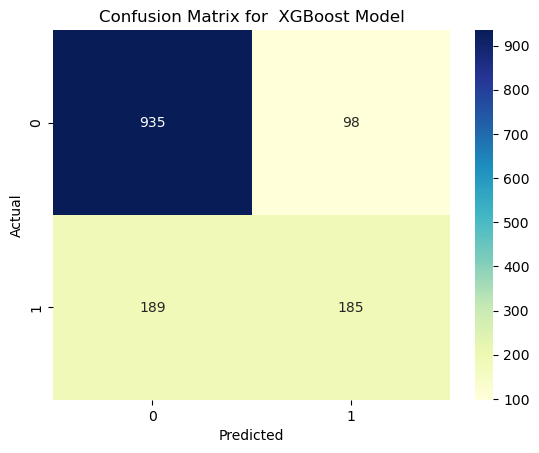

In [80]:
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix for  XGBoost Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [81]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.80      0.79      1407



### Feature Importance – XGBoost

XGBoost provides feature importance scores that help identify which variables contribute most to predicting customer churn.

The visualization below highlights the most influential features in the model.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

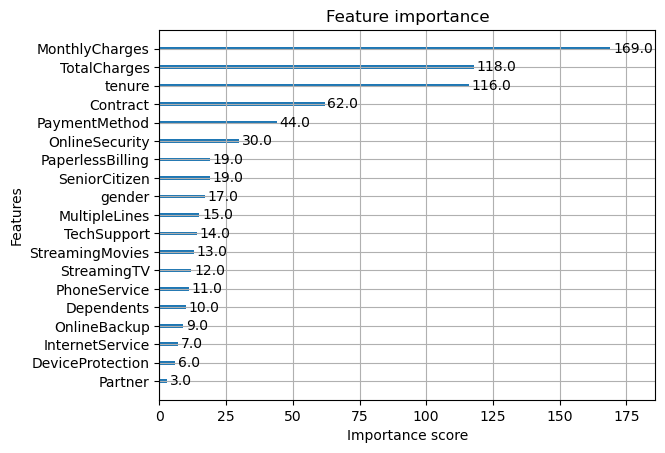

In [82]:
plot_importance(xgb_model)


In [83]:
# Storing trained (preferably tuned) models here
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "KNN": knn, 
    "XGBoost": xgb_model
}



In [84]:
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "F1 Score": f1,
        "ROC-AUC": roc
    })

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)

results_df

,Model,F1 Score,ROC-AUC
4,XGBoost,0.563166,0.835576
0,Logistic Regression,0.614271,0.829698
2,Random Forest,0.525661,0.816114
1,Decision Tree,0.584582,0.806339
3,KNN,0.471002,0.784652


In [85]:
cv_results = {}

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="roc_auc"
    )
    
    cv_results[name] = scores.mean()

cv_results

{'Logistic Regression': np.float64(0.8439599464461593),
 'Decision Tree': np.float64(0.826583959101006),
 'Random Forest': np.float64(0.8218377617284428),
 'KNN': np.float64(0.791446182820688),
 'XGBoost': np.float64(0.8460585274078888)}

In [86]:
cv_df = pd.DataFrame.from_dict(
    cv_results, orient="index", columns=["CV ROC-AUC"]
).sort_values(by="CV ROC-AUC", ascending=False)

cv_df

,CV ROC-AUC
XGBoost,0.846059
Logistic Regression,0.843960
Decision Tree,0.826584
Random Forest,0.821838
KNN,0.791446


In [87]:
best_model_name = cv_df.index[0]
best_model_name

'XGBoost'

In [88]:
with open("model_columns.pkl", "wb") as f:
    pickle.dump(model_columns, f)

In [90]:
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [89]:
print(len(model_columns))
print(model_columns[:10])

30
['tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes']


## Model Comparison, Cross-Validation, and Hyperparameter Tuning

To identify the most effective model for predicting customer churn, multiple machine learning models were trained and evaluated using **F1-score** and **ROC-AUC**.

- **F1-score** was used because churn prediction often involves class imbalance, and this metric balances **precision and recall**.
- **ROC-AUC** measures the model's ability to distinguish between churned and non-churned customers across different classification thresholds.

Based on these metrics, **XGBoost** emerged as the best-performing model.

### Cross-Validation

To ensure the model's performance was not dependent on a single train-test split, **5-fold cross-validation** was applied. Cross-validation provides a more reliable estimate of model performance by training and validating the model on different subsets of the data.

This process helps confirm that the selected model generalizes well to unseen data.


# Business Recommendations  
## Based on Churn Prediction Model Results

---

## 6.1 Key Findings from the Predictive Models

The churn prediction models (Logistic Regression, Random Forest, and Decision Tree) consistently identified the following key drivers of customer churn:

- **Contract Type (Month-to-month)** significantly increases churn probability.
- **High Monthly Charges** are strongly associated with higher churn.
- **Short Tenure** customers are more likely to leave.
- **Fiber Optic Internet Users** exhibit elevated churn risk.
- **High Total Charges** correlate with churn behavior.
- **Lack of Online Security or Add-on Services** increases churn likelihood.
- **Electronic Check Payment Method** is linked to higher churn rates.

These findings indicate that churn is primarily driven by:
- Low customer commitment  
- Pricing pressure  
- Limited service engagement  

---

## 6.2 High-Risk Customer Segments Identified

Based on the model outputs, the most vulnerable customer groups are:

- Month-to-month contract subscribers  
- Customers with short tenure  
- High monthly charge customers  
- Fiber-optic internet users  
- Customers without add-on services (e.g., online security)  
- Customers using electronic check payments  

These segments should be prioritized for retention efforts.

---

## 6.3 Recommended Retention Strategies

### 1. Contract Conversion Strategy

**Model Insight:**  
Month-to-month contracts are the strongest churn predictor.

**Recommendation:**  
- Offer discounts for switching to 12- or 24-month contracts  
- Provide loyalty rewards for long-term commitments  
- Introduce contract upgrade campaigns  

**Expected Impact:**  
Increased customer commitment and reduced churn probability.

---

### 2. Pricing Optimization Strategy

**Model Insight:**  
High monthly charges significantly increase churn risk.

**Recommendation:**  
- Introduce bundled service packages  
- Offer tiered pricing plans  
- Provide loyalty discounts for high-value customers  

**Expected Impact:**  
Reduced price sensitivity and improved retention among premium users.

---

### 3. Early-Tenure Engagement Program

**Model Insight:**  
Customers with short tenure are more likely to churn.

**Recommendation:**  
- Implement structured onboarding programs  
- Offer welcome incentives for the first 90 days  
- Conduct early follow-up engagement campaigns  

**Expected Impact:**  
Stronger early customer relationships and increased lifetime value.

---

### 4. Fiber Service Quality Enhancement

**Model Insight:**  
Fiber-optic users show higher churn risk.

**Recommendation:**  
- Improve service reliability and speed consistency  
- Provide priority technical support  
- Offer service satisfaction guarantees  

**Expected Impact:**  
Reduced dissatisfaction among high-expectation customers.

---

### 5. Add-On Service Adoption Campaign

**Model Insight:**  
Customers without online security or additional services churn more.

**Recommendation:**  
- Bundle online security with internet plans  
- Offer free trials of add-on services  
- Promote value-added service awareness  

**Expected Impact:**  
Higher service engagement and lower churn probability.

---

### 6. Payment Method Optimization

**Model Insight:**  
Electronic check users have higher churn rates.

**Recommendation:**  
- Incentivize auto-pay or credit/debit card billing  
- Offer small discounts for automatic payments  
- Simplify digital payment enrollment  

**Expected Impact:**  
More stable billing relationships and improved customer retention.

---

## 6.4 Overall Business Impact

By targeting high-risk customers identified through predictive modeling, the company can:

- Reduce overall churn rate  
- Increase customer lifetime value  
- Improve recurring revenue stability  
- Retain high-value customer segments  

---

## 6.5 Strategic Conclusion

The churn prediction analysis reveals that customer attrition is largely influenced by contract flexibility, pricing pressure, and service engagement levels.

Implementing targeted retention strategies focused on:
- Contract upgrades  
- Pricing optimization  
- Early customer engagement  
- Service bundling  

will significantly reduce churn and improve long-term revenue growth.